# SVM Flower Image Classification

Notebook này xây dựng hệ thống nhận diện ảnh hoa bằng **SVM (Support Vector Machine)**.

Pipeline:
```text
Load ảnh → Resize 32x32 → Flatten 3072 số → Train/Validation/Test
→ Mean subtraction → StandardScaler → Linear SVM → Tune C
→ Test → Save best_svm_flower.joblib → Predict ảnh mới
```

In [1]:
import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

CLASSES = ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
IMG_SIZE = (32, 32)
DATASET_DIR = 'flower-training'
RANDOM_STATE = 42

## 1. Load dữ liệu ảnh

Mỗi folder là một loại hoa. Ảnh nằm trong folder nào thì nhận nhãn của folder đó.

```text
daisy → 0
dandelion → 1
rose → 2
sunflower → 3
tulip → 4
```

In [2]:
def load_flower_data(data_dir=DATASET_DIR, img_size=IMG_SIZE):
    X = []
    y = []

    for label, cls in enumerate(CLASSES):
        cls_dir = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_dir):
            raise FileNotFoundError(f'Folder not found: {cls_dir}')

        for filename in os.listdir(cls_dir):
            if not filename.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                continue
            img_path = os.path.join(cls_dir, filename)
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(img_size)
                X.append(np.array(img))
                y.append(label)
            except Exception as e:
                print(f'Skipping {img_path}: {e}')

    X = np.array(X).astype('float64')
    y = np.array(y)

    np.random.seed(RANDOM_STATE)
    idxs = np.random.permutation(len(X))
    X = X[idxs]
    y = y[idxs]

    return X, y

X, y = load_flower_data()
print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (2746, 32, 32, 3)
y shape: (2746,)


## 2. Hiển thị ảnh mẫu

Cell này chỉ để kiểm tra ảnh đã load đúng chưa. Nó không ảnh hưởng đến model.

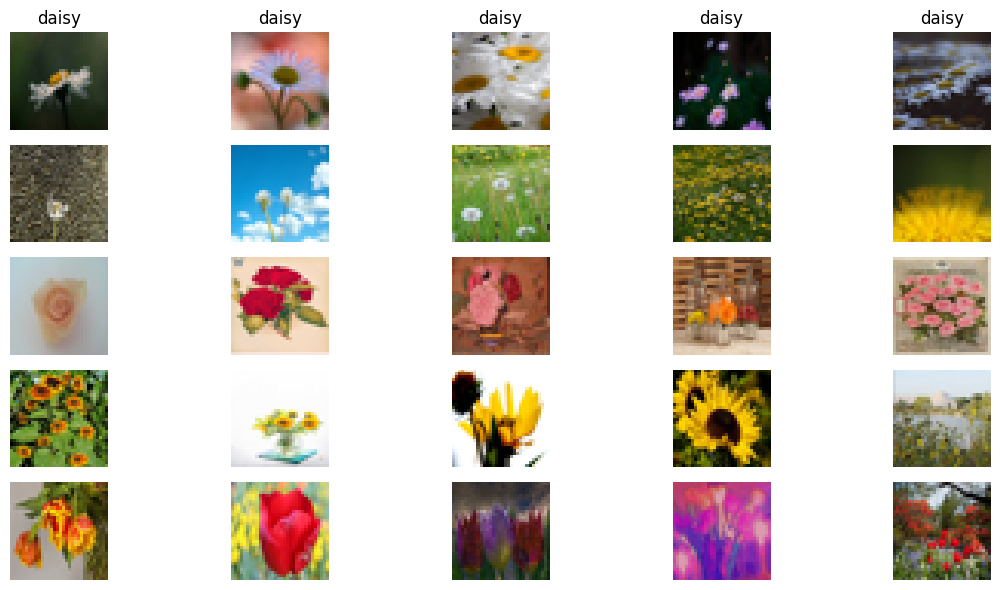

In [3]:
samples_per_class = 5
plt.figure(figsize=(12, 6))

plot_index = 1
for cls_idx, cls_name in enumerate(CLASSES):
    idxs = np.where(y == cls_idx)[0]
    selected = idxs[:samples_per_class]

    for idx in selected:
        plt.subplot(len(CLASSES), samples_per_class, plot_index)
        plt.imshow(X[idx].astype('uint8'))
        plt.axis('off')
        if plot_index <= samples_per_class:
            plt.title(cls_name)
        plot_index += 1

plt.tight_layout()
plt.show()

## 3. Chia train / validation / test

- **Train set**: cho SVM học.
- **Validation set**: chọn giá trị `C` tốt nhất.
- **Test set**: đánh giá cuối cùng.

Dữ liệu được chia 80% train raw và 20% test. Train raw tiếp tục chia 90% train và 10% validation.

In [4]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.1, random_state=RANDOM_STATE, stratify=y_train
)

print('Train:', X_train_raw.shape, y_train.shape)
print('Validation:', X_val_raw.shape, y_val.shape)
print('Test:', X_test_raw.shape, y_test.shape)

Train: (1976, 32, 32, 3) (1976,)
Validation: (220, 32, 32, 3) (220,)
Test: (550, 32, 32, 3) (550,)


## 4. Tiền xử lý dữ liệu

Ảnh ban đầu có dạng `32 x 32 x 3`. Sau khi flatten, mỗi ảnh thành vector `3072` giá trị.

SVM nhạy với thang đo dữ liệu, nên sau khi trừ `mean_image`, ta dùng thêm `StandardScaler`.

In [5]:
X_train = X_train_raw.reshape(X_train_raw.shape[0], -1)
X_val = X_val_raw.reshape(X_val_raw.shape[0], -1)
X_test = X_test_raw.reshape(X_test_raw.shape[0], -1)

mean_image = np.mean(X_train, axis=0)
X_train = X_train - mean_image
X_val = X_val - mean_image
X_test = X_test - mean_image

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)

X_train: (1976, 3072)
X_val: (220, 3072)
X_test: (550, 3072)


## 5. Train thử SVM baseline

Ở đây dùng `LinearSVC`, tức là SVM tuyến tính. Mô hình học các ranh giới phân loại giữa 5 loại hoa.

In [6]:
svm = LinearSVC(C=1.0, class_weight='balanced', max_iter=10000, random_state=RANDOM_STATE)
svm.fit(X_train, y_train)

y_train_pred = svm.predict(X_train)
y_val_pred = svm.predict(X_val)

print('Baseline train accuracy:', accuracy_score(y_train, y_train_pred))
print('Baseline validation accuracy:', accuracy_score(y_val, y_val_pred))

Baseline train accuracy: 0.9984817813765182
Baseline validation accuracy: 0.39090909090909093


/Users/phuongtran/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## 6. Tune tham số C

`C` điều khiển mức độ nghiêm khắc với lỗi phân loại.

- `C` nhỏ: margin rộng hơn, model mềm hơn.
- `C` lớn: model cố đúng trên train hơn, dễ overfitting hơn.

Model tốt nhất được chọn theo **validation accuracy**.

In [7]:
C_values = [0.001, 0.01, 0.1, 1, 10]

results = {}
best_val = -1
best_svm = None
best_params = None

for C in C_values:
    model = LinearSVC(C=C, class_weight='balanced', max_iter=10000, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    results[C] = {'train_accuracy': train_acc, 'validation_accuracy': val_acc}
    print(f'C={C:<6} | train acc={train_acc:.4f} | val acc={val_acc:.4f}')

    if val_acc > best_val:
        best_val = val_acc
        best_svm = model
        best_params = {'C': C}

print('\nBest validation accuracy:', best_val)
print('Best parameters:', best_params)

C=0.001  | train acc=0.8699 | val acc=0.4818
C=0.01   | train acc=0.9904 | val acc=0.3955


/Users/phuongtran/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C=0.1    | train acc=0.9995 | val acc=0.3727


/Users/phuongtran/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


C=1      | train acc=0.9985 | val acc=0.3909
C=10     | train acc=0.9985 | val acc=0.3864

Best validation accuracy: 0.4818181818181818
Best parameters: {'C': 0.001}


/Users/phuongtran/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## 7. Đánh giá trên test set

Sau khi chọn được `best_svm`, model được đánh giá trên test set bằng accuracy, classification report và confusion matrix.

In [8]:
y_test_pred = best_svm.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print('SVM test accuracy:', test_accuracy)

print('\nClassification report:')
print(classification_report(y_test, y_test_pred, target_names=CLASSES))

print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_test_pred))

SVM test accuracy: 0.4636363636363636

Classification report:
              precision    recall  f1-score   support

       daisy       0.46      0.37      0.41       100
   dandelion       0.42      0.54      0.48       129
        rose       0.46      0.49      0.48       100
   sunflower       0.55      0.63      0.59        99
       tulip       0.43      0.30      0.36       122

    accuracy                           0.46       550
   macro avg       0.47      0.47      0.46       550
weighted avg       0.46      0.46      0.46       550


Confusion matrix:
[[37 35 11  7 10]
 [20 70 11 19  9]
 [ 6 18 49  6 21]
 [ 5 16  7 62  9]
 [13 26 28 18 37]]


## 8. Lưu model

File `.joblib` lưu model và các bước xử lý cần dùng lại khi dự đoán ảnh mới.

In [9]:
joblib.dump({
    'model': best_svm,
    'classes': CLASSES,
    'img_size': IMG_SIZE,
    'mean_image': mean_image,
    'scaler': scaler,
    'best_params': best_params,
    'results': results,
    'model_type': 'LinearSVC'
}, 'best_svm_flower.joblib')

print('Saved: best_svm_flower.joblib')

Saved: best_svm_flower.joblib


## 9. Dự đoán ảnh mới

SVM không trả về xác suất như Random Forest trong bản `LinearSVC`. Nó trả về `decision score`. Class có score cao nhất được chọn.

In [11]:
def predict_single_image(image_path, model_package_path='best_svm_flower.joblib'):
    package = joblib.load(model_package_path)

    model = package['model']
    classes = package['classes']
    img_size = package['img_size']
    mean_image = package['mean_image']
    scaler = package['scaler']

    img = Image.open(image_path).convert('RGB')
    img = img.resize(img_size)

    arr = np.array(img).astype('float64').reshape(1, -1)
    arr = arr - mean_image
    arr = scaler.transform(arr)

    pred = model.predict(arr)[0]
    scores = model.decision_function(arr)[0]

    print('Predicted class:', classes[pred])
    print('\nDecision scores:')
    for cls, score in zip(classes, scores):
        print(f'{cls}: {score:.4f}')

    return classes[pred], scores

# Ví dụ:
predict_single_image('flower-training/sunflower/9558627290_353a14ba0b_m.jpg')

Predicted class: sunflower

Decision scores:
daisy: -0.6200
dandelion: -1.6774
rose: -0.7933
sunflower: 0.8191
tulip: -0.4491


('sunflower',
 array([-0.61996043, -1.67741442, -0.79329762,  0.81907121, -0.44914266]))